# Description

Prove that the Noise Reduction model works on a 2D polinomial.

Add libs folder path to system variables in order to make the importation of local libraries easier.

In [95]:
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

Import external and local libraries

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from tqdm import tqdm
import math
from typing import List

# Locals
from utils import *
from dataset import Dataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction

Global / Path variables

In [97]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

Make sure that the GPU is being used

In [98]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

Functions definition

In [99]:
def polinomial_function(x:float):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6


def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

Generate 2D data with normal distribution at the points indicated in ‘means’ variable.  
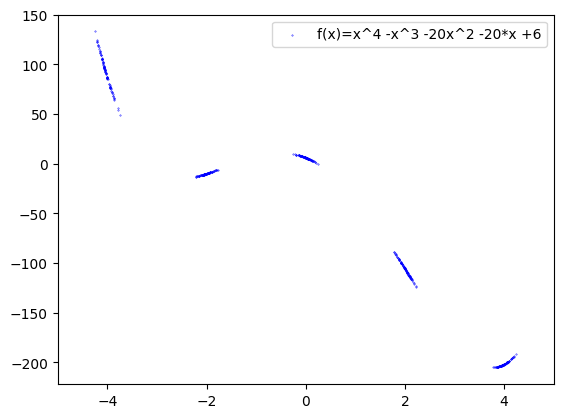

In [100]:
means = [-4, -2, 0, 2, 4]
X_train = [np.random.normal(loc=m, scale=0.1, size=(100)) for m in means]
X_train = np.concatenate(X_train, axis=0)
y_train = polinomial_function(X_train)

df_train = pd.DataFrame({'X': X_train, 'y': y_train})

Generate continious 2D data like so  
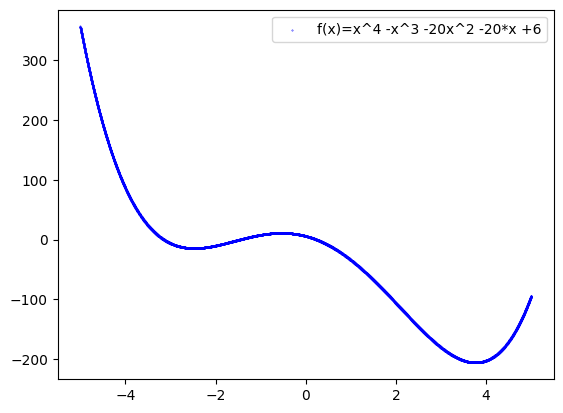

In [101]:
X_train = np.linspace(-5, 5, 10001)
y_train = polinomial_function(X_train)

df_train = pd.DataFrame({'X': X_train, 'y': y_train})

Copy the dataframe into validation, test and noisy dataframes

In [102]:
df_val = df_train.copy()
df_test = df_train.copy()
df_noisy = df_train.copy()

Scale the noisy dataframe into [0,1] domain

In [103]:
scaler = MinMaxScaler()
df_train = pd.DataFrame(scaler.fit_transform(df_train), columns=['X', 'y'])
df_val = pd.DataFrame(scaler.transform(df_val), columns=['X', 'y'])
df_test = pd.DataFrame(scaler.transform(df_test), columns=['X', 'y'])
df_noisy = pd.DataFrame(scaler.transform(df_noisy), columns=['X', 'y'])

# No noise XAI Benchmarck

In [104]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {"dual": 'auto'},
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
}
xai_benchmark = XAI_benchmark(is_ts = False, model_params = model_params)

In [105]:
xai_benchmark.fit(df_train[['X']], df_train['y'].values)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [106]:
xai_benchmark.predict(df_val[['X']], df_val['y'].values, get_metrics=True)

({'ridge': array([ 0.61363133,  0.61356904,  0.61350674, ..., -0.00917183,
         -0.00923412, -0.00929641]),
  'pls': array([ 0.61400497,  0.61394261,  0.61388024, ..., -0.00954532,
         -0.00960769, -0.00967006]),
  'decision_tree': array([0.97003401, 0.97003401, 0.97003401, ..., 0.18368235, 0.18368235,
         0.18368235]),
  'svm': array([ 0.58754304,  0.58748375,  0.58742446, ..., -0.00523118,
         -0.00529047, -0.00534976]),
  'knn': array([0.99859395, 0.99859395, 0.99859395, ..., 0.19747153, 0.19747153,
         0.19747153])},
 {'ridge': {'mse': 0.008701494046364446,
   'rmse': 0.09328179911625015,
   'mae': 0.07385627189820987,
   'R2': 0.788398814336787},
  'pls': {'mse': 0.00870144750030884,
   'rmse': 0.0932815496242898,
   'mae': 0.07386406538368075,
   'R2': 0.7883999462344246},
  'decision_tree': {'mse': 0.000194571417870038,
   'rmse': 0.013948885900674576,
   'mae': 0.011752649359040728,
   'R2': 0.9952684513144413},
  'svm': {'mse': 0.00890298849512892,
   '

Add goussian noise to the dataframe

In [107]:
sigma = 0.07
df_noisy = add_gaussian_noise(
        df=df_noisy.copy(),
        columns=[x for x in df_train.columns],
        mean=0,
        std=sigma
)

Plot the new noisy data

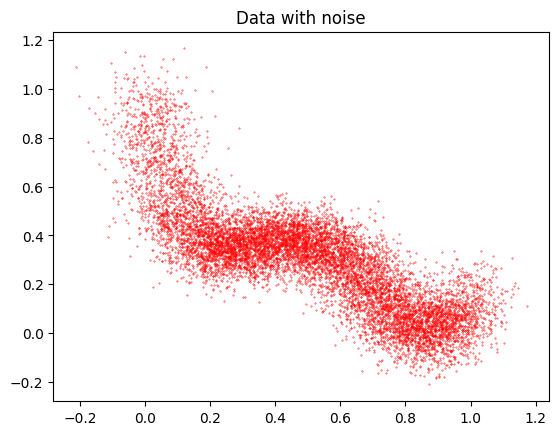

In [108]:
plt.title('Data with noise')
plt.scatter(df_noisy['X'], df_noisy['y'], color='r', s=0.1)

# Noisy XAI Benchmarck

In [109]:
xai_benchmark.fit(df_noisy[['X']], df_noisy['y'].values)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [110]:
xai_benchmark.predict(df_val[['X']], df_val['y'].values, get_metrics=True)

({'ridge': array([0.59712102, 0.59706189, 0.59700275, ..., 0.00589496, 0.00583583,
         0.00577669]),
  'pls': array([0.59745693, 0.59739773, 0.59733852, ..., 0.00555839, 0.00549919,
         0.00543999]),
  'decision_tree': array([0.59189306, 0.59189306, 0.59189306, ..., 0.07103371, 0.07103371,
         0.07103371]),
  'svm': array([0.56545312, 0.56539863, 0.56534414, ..., 0.0206589 , 0.02060441,
         0.02054992]),
  'knn': array([0.76319744, 0.76319744, 0.75058279, ..., 0.12964707, 0.12964707,
         0.12964707])},
 {'ridge': {'mse': 0.008789087487126278,
   'rmse': 0.09375013326457876,
   'mae': 0.07370739091892844,
   'R2': 0.7862687346260198},
  'pls': {'mse': 0.00878550070613283,
   'rmse': 0.09373100184108153,
   'mae': 0.07370513683287393,
   'R2': 0.7863559572462828},
  'decision_tree': {'mse': 0.0030198130976005033,
   'rmse': 0.05495282611113375,
   'mae': 0.03178071193610656,
   'R2': 0.9265647912267958},
  'svm': {'mse': 0.009302648646507948,
   'rmse': 0.0964502

Create Datasets for DataLoaders

In [111]:
# Transform the data into a tensor
bio_dataset_train = Dataset(
    input_df=df_noisy[['X']],
    target_df=df_noisy[['y']]
)
# Transform the data into a tensor
bio_dataset_val = Dataset(
    input_df=df_val[['X']],
    target_df=df_val[['y']]
)

# Create the dataloaders
batch_size = 64
train_dataloader = DataLoader(bio_dataset_train, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(bio_dataset_val, batch_size=batch_size, shuffle=True, num_workers=0)

Create Neural Network model

In [112]:
model = GridFullyDenseNN(
    n_layers=2,
    hidden_layers=[
        (1, 1024),
        (1024, 1),
    ],
    dropout_layers=[
        0.0,
        0.0,
    ],
    activation_func_layers=[
        nn.ReLU(),
        nn.Identity(),
    ],
    want_dropout=[
        False,
        False,
    ],
    want_linear=[
        True,
        True,
    ],
    want_activation=[
        True,
        False,
    ],
)
model.to(device)

GridFullyDenseNN(
  (model): Sequential(
    (linear_0): Linear(in_features=1, out_features=1024, bias=True)
    (activation_0): ReLU()
    (linear_1): Linear(in_features=1024, out_features=1, bias=True)
  )
)

Set model parameters and create the model Trainer object

In [113]:
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_polinomial')
)

Train the model

In [114]:
# model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

or load a checkpoint

In [115]:
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_polinomial.pth')))

<All keys matched successfully>

Predict over the datasets

In [116]:
y_pred_test = model(torch.tensor(df_test['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [117]:
y_pred_val = model(torch.tensor(df_val['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [118]:
y_pred_train = model(torch.tensor(df_noisy['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [119]:
y_pred_noisy = model(torch.tensor(df_noisy['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

Show the metrics

In [120]:
gt_values = df_test['y'].values
predicted_values = y_pred_test

In [121]:
mae = mean_absolute_error(gt_values, predicted_values)
mse = mean_squared_error(gt_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs(gt_values - predicted_values) / gt_values) * 100
r_squared = r2_score(gt_values, predicted_values)
print("MAE: ", mae)
print("MAPE: ", mape)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R-squared: ", r_squared)

MAE:  0.0305805998153636
MAPE:  inf
MSE:  0.0022577882645267154
RMSE:  0.04751618949922979
R-squared:  0.945095558164526


/tmp/ipykernel_1366067/806501063.py:4: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs(gt_values - predicted_values) / gt_values) * 100


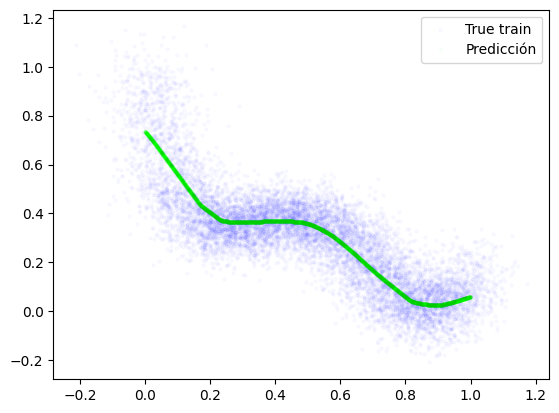

In [122]:
plt.scatter(df_noisy['X'].values, df_noisy['y'].values, color='b', label='True train', s=5, alpha=0.02)
# plt.scatter(df_noisy['X'].values, y_pred_train, color='cyan', label='Pred train', s=5, alpha=0.02)
# plt.scatter(df_val['X'].values, y_pred_val, color='pink', label='Pred val', s=5, alpha=0.02)
plt.scatter(df_test['X'].values, y_pred_test, color='lime', label='Predicción', s=5, alpha=0.02)
plt.legend()
plt.show()

# Gradients to reduce noise

In [123]:
df_no_noise = df_noisy.copy()
dlnr = DLNoiseReduction(model=model, criterion=criterion)
dlnr.fit(df_noisy['X'].values.reshape(-1, 1), df_noisy['y'].values.reshape(-1, 1))

In [124]:
df_no_noise['X'], df_no_noise['y'] = dlnr.transform(
                                                nrr=0.05,
                                                nr_threshold=0.01,
                                                max_epochs=200,
                                                plot_progress=False
)

In [125]:
# dlnr.fit(df_no_noise['X'].values.reshape(-1, 1), df_no_noise['y'].values.reshape(-1, 1))
# df_no_noise['X'], df_no_noise['y'] = dlnr.transform(
#     nrr=0.05,
#     nr_threshold=0.01,
#     max_epochs=100,
#     plot_progress=True
# )

In [126]:
dlnr.assert_improvement(
    x_denoised = df_no_noise['X'].values.reshape(-1, 1),
    y_denoised = df_no_noise['y'].values.reshape(-1, 1),
    x_orig = df_train['X'].values.reshape(-1, 1),
    y_orig = df_train['y'].values.reshape(-1, 1)
)

X noisy median error: 0.04662761309652297
X denoised median error: 0.03771622215618897
Y noisy median error: 0.0468541758713914
Y denoised median error: 0.023762012518560083


True

# Denoised XAI Benchmark

In [127]:
xai_benchmark.fit(df_no_noise[['X']], df_no_noise['y'].values)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [128]:
xai_benchmark.predict(df_val[['X']], df_val['y'].values, get_metrics=True)

({'ridge': array([ 0.6146455 ,  0.61458281,  0.61452011, ..., -0.01215118,
         -0.01221387, -0.01227656]),
  'pls': array([ 0.6149991 ,  0.61493634,  0.61487357, ..., -0.01250421,
         -0.01256697, -0.01262973]),
  'decision_tree': array([0.74830163, 0.74830163, 0.74830163, ..., 0.07813346, 0.07813346,
         0.07813346]),
  'svm': array([ 0.59926654,  0.59920524,  0.59914394, ..., -0.01359707,
         -0.01365837, -0.01371967]),
  'knn': array([0.74572233, 0.7451809 , 0.7451809 , ..., 0.0639302 , 0.0639302 ,
         0.0639302 ])},
 {'ridge': {'mse': 0.008703292548410986,
   'rmse': 0.09329143877339971,
   'mae': 0.07385103769941886,
   'R2': 0.7883550787250131},
  'pls': {'mse': 0.008703716323890803,
   'rmse': 0.0932937099910321,
   'mae': 0.07385996064765453,
   'R2': 0.7883447734379547},
  'decision_tree': {'mse': 0.0022759484053345084,
   'rmse': 0.04770690102421775,
   'mae': 0.02987940353898524,
   'R2': 0.9446539435054496},
  'svm': {'mse': 0.008799218022075858,
  